In [67]:
import mysql.connector
from mysql.connector import Error
import pandas as pd
import warnings
warnings.filterwarnings("ignore")
# MySQL Connection
conn = mysql.connector.connect(
    host = "localhost",
    user = "root"      ,
    password = "parth004",
    database = "dummy"
)

# Employees Table
employees = pd.read_sql("SELECT * FROM employees", conn)

# Customers Table
customers = pd.read_sql("SELECT * FROM customers", conn)

# Offices Table
offices = pd.read_sql("SELECT * FROM offices", conn)

# Payments Table
payments = pd.read_sql("SELECT * FROM payments", conn)

# Orders Table
orders = pd.read_sql("SELECT * FROM orders", conn)

# Order Details Table
orderdetails = pd.read_sql("SELECT * FROM orderdetails", conn)

# Product Name Table
products = pd.read_sql("SELECT * FROM products", conn)

# Product Line Table
productlines = pd.read_sql("SELECT * FROM productlines", conn)

# Close connection
conn.close()

In [4]:
# Display the first 5 rows.
customers.head()

,customerNumber,customerName,contactLastName,contactFirstName,phone,addressLine1,addressLine2,city,state,postalCode,country,salesrepemployeenumber,creditLimit
0,103,bhopal,Schmitt,Carine,40.32.2555,"54, rue Royale",None,Nantes,None,44000,France,1370.0,22000.0
1,112,Signal Gift Stores,King,Jean,7025551838,8489 Strong St.,None,Las Vegas,NV,83030,USA,1166.0,71800.0
2,114,"Australian Collectors, Co.",Ferguson,Peter,03 9520 4555,636 St Kilda Road,Level 3,Melbourne,Victoria,3004,Australia,1611.0,117300.0
3,119,La Rochelle Gifts,Labrune,Janine,40.67.8555,"67, rue des Cinquante Otages",None,Nantes,None,44000,France,1370.0,118200.0
4,121,Baane Mini Imports,Bergulfsen,Jonas,07-98 9555,Erling Skakkes gate 78,None,Stavern,None,4110,Norway,1504.0,81700.0


In [8]:
# Check the shape (rows, columns) of the products DataFrame.
customers.shape

(122, 13)

In [12]:
# Get summary statistics (describe()) of the products DataFrame.
products.describe()

,quantityInStock,buyPrice,MSRP
count,110.000000,110.000000,110.000000
mean,5046.645455,54.395182,100.438727
std,2939.263668,22.051130,39.663649
min,15.000000,15.910000,33.190000
25%,2419.000000,34.180000,68.907500
50%,5437.500000,53.915000,98.300000
75%,7599.750000,68.675000,122.850000
max,9997.000000,103.420000,214.300000


In [15]:
# Check for missing values in the customers DataFrame.
customers.isna().sum()

customerNumber              0
customerName                0
contactLastName             0
contactFirstName            0
phone                       0
addressLine1                0
addressLine2              100
city                        0
state                      73
postalCode                  7
country                     0
salesrepemployeenumber     22
creditLimit                 0
dtype: int64

In [21]:
# Select only the productName and MSRP columns.
products[["productName","MSRP"]]

,productName,MSRP
0,1969 Harley Davidson Ultimate Chopper,95.70
1,1952 Alpine Renault 1300,214.30
2,1996 Moto Guzzi 1100i,118.94
3,2003 Harley-Davidson Eagle Drag Bike,193.66
4,1972 Alfa Romeo GTA,136.00
...,...,...
105,The Titanic,100.17
106,The Queen Mary,99.31
107,American Airlines: MD-11S,74.03
108,Boeing X-32A JSF,49.66


In [31]:
# Filter products where quantityInStock < 1000.
products[products['quantityInStock']>1000]

,productCode,productName,productLine,productScale,productVendor,productDescription,quantityInStock,buyPrice,MSRP
0,S10_1678,1969 Harley Davidson Ultimate Chopper,Motorcycles,1:10,Min Lin Diecast,"This replica features working kickstand, front...",7933,48.81,95.70
1,S10_1949,1952 Alpine Renault 1300,Classic Cars,1:10,Classic Metal Creations,Turnable front wheels; steering function; deta...,7305,98.58,214.30
2,S10_2016,1996 Moto Guzzi 1100i,Motorcycles,1:10,Highway 66 Mini Classics,"Official Moto Guzzi logos and insignias, saddl...",6625,68.99,118.94
3,S10_4698,2003 Harley-Davidson Eagle Drag Bike,Motorcycles,1:10,Red Start Diecast,"Model features, official Harley Davidson logos...",5582,91.02,193.66
4,S10_4757,1972 Alfa Romeo GTA,Classic Cars,1:10,Motor City Art Classics,Features include: Turnable front wheels; steer...,3252,85.68,136.00
...,...,...,...,...,...,...,...,...,...
103,S700_2834,ATA: B757-300,Planes,1:700,Highway 66 Mini Classics,Exact replia with official logos and insignias...,7106,59.33,118.65
105,S700_3505,The Titanic,Ships,1:700,Carousel DieCast Legends,"Completed model measures 19 1/2 inches long, 9...",1956,51.09,100.17
106,S700_3962,The Queen Mary,Ships,1:700,Welly Diecast Productions,Exact replica. Wood and Metal. Many extras inc...,5088,53.63,99.31
107,S700_4002,American Airlines: MD-11S,Planes,1:700,Second Gear Diecast,Polished finish. Exact replia with official lo...,8820,36.27,74.03


In [33]:
# Sort the products DataFrame by buyPrice descending.
products.sort_values(by='buyPrice', ascending=False)

,productCode,productName,productLine,productScale,productVendor,productDescription,quantityInStock,buyPrice,MSRP
5,S10_4962,1962 LanciaA Delta 16V,Classic Cars,1:10,Second Gear Diecast,Features include: Turnable front wheels; steer...,6791,103.42,147.74
25,S18_2238,1998 Chrysler Plymouth Prowler,Classic Cars,1:18,Gearbox Collectibles,Turnable front wheels; steering function; deta...,4724,101.51,163.73
1,S10_1949,1952 Alpine Renault 1300,Classic Cars,1:10,Classic Metal Creations,Turnable front wheels; steering function; deta...,7305,98.58,214.30
77,S24_3856,1956 Porsche 356A Coupe,Classic Cars,1:18,Classic Metal Creations,Features include: Turnable front wheels; steer...,6600,98.30,140.43
7,S12_1108,2001 Ferrari Enzo,Classic Cars,1:12,Second Gear Diecast,Turnable front wheels; steering function; deta...,3619,95.59,207.80
...,...,...,...,...,...,...,...,...,...
60,S24_1937,1939 Chevrolet Deluxe Coupe,Vintage Cars,1:24,Motor City Art Classics,This 1:24 scale die-cast replica of the 1939 C...,7332,22.57,33.19
79,S24_3969,1936 Mercedes Benz 500k Roadster,Vintage Cars,1:24,Red Start Diecast,This model features grille-mounted chrome horn...,2081,21.75,41.03
63,S24_2022,1938 Cadillac V-16 Presidential Limousine,Vintage Cars,1:24,Classic Metal Creations,This 1:24 scale precision die cast replica of ...,2847,20.61,44.80
70,S24_2972,1982 Lamborghini Diablo,Classic Cars,1:24,Second Gear Diecast,"This replica features opening doors, superb de...",7723,16.24,37.76


In [70]:
# Find the mean, median, and mode of MSRP in products.
print(products['MSRP'].mean())
print(products['MSRP'].median())
print(products['MSRP'].mode())
sum=0
count=0
for i in products['MSRP']:
    sum=sum+i
    count=count+1
mean=sum/count
print(mean)
# smsrp=products['MSRP'].sort_values
# print(smsrp)
# if count % 2 == 0:
#     median = (smsrp.iloc[count//2 - 1] + smsrp.iloc[count//2]) / 2
# else:
#     median = smsrp.iloc[count//2]

100.43872727272728
98.3
0     50.31
1    117.44
Name: MSRP, dtype: float64
100.43872727272729


In [73]:
# Create a new column profit = MSRP - buyPrice in the products DataFrame.
for i in range(len(products)):
    products['profit']=products['MSRP']-products['buyPrice']
products

,productCode,productName,productLine,productScale,productVendor,productDescription,quantityInStock,buyPrice,MSRP,profit
0,S10_1678,1969 Harley Davidson Ultimate Chopper,Motorcycles,1:10,Min Lin Diecast,"This replica features working kickstand, front...",7933,48.81,95.70,46.89
1,S10_1949,1952 Alpine Renault 1300,Classic Cars,1:10,Classic Metal Creations,Turnable front wheels; steering function; deta...,7305,98.58,214.30,115.72
2,S10_2016,1996 Moto Guzzi 1100i,Motorcycles,1:10,Highway 66 Mini Classics,"Official Moto Guzzi logos and insignias, saddl...",6625,68.99,118.94,49.95
3,S10_4698,2003 Harley-Davidson Eagle Drag Bike,Motorcycles,1:10,Red Start Diecast,"Model features, official Harley Davidson logos...",5582,91.02,193.66,102.64
4,S10_4757,1972 Alfa Romeo GTA,Classic Cars,1:10,Motor City Art Classics,Features include: Turnable front wheels; steer...,3252,85.68,136.00,50.32
...,...,...,...,...,...,...,...,...,...,...
105,S700_3505,The Titanic,Ships,1:700,Carousel DieCast Legends,"Completed model measures 19 1/2 inches long, 9...",1956,51.09,100.17,49.08
106,S700_3962,The Queen Mary,Ships,1:700,Welly Diecast Productions,Exact replica. Wood and Metal. Many extras inc...,5088,53.63,99.31,45.68
107,S700_4002,American Airlines: MD-11S,Planes,1:700,Second Gear Diecast,Polished finish. Exact replia with official lo...,8820,36.27,74.03,37.76
108,S72_1253,Boeing X-32A JSF,Planes,1:72,Motor City Art Classics,"10"" Wingspan with retractable landing gears.Co...",4857,32.77,49.66,16.89


In [97]:
# Count how many unique productLine values exist.
print(products['productLine'].unique())
products['productLine'].value_counts()

['Motorcycles' 'Classic Cars' 'Trucks and Buses' 'Vintage Cars' 'Planes'
 'Ships' 'Trains']


productLine
Classic Cars        38
Vintage Cars        24
Motorcycles         13
Planes              12
Trucks and Buses    11
Ships                9
Trains               3
Name: count, dtype: int64

In [100]:
# Group products by productLine and find the average MSRP for each.
products.groupby('productLine')['MSRP'].mean()
products.groupby('productLine')['MSRP'].mean()

productLine
Classic Cars        118.021053
Motorcycles          97.178462
Planes               89.515833
Ships                86.563333
Trains               73.853333
Trucks and Buses    103.183636
Vintage Cars         87.095833
Name: MSRP, dtype: float64

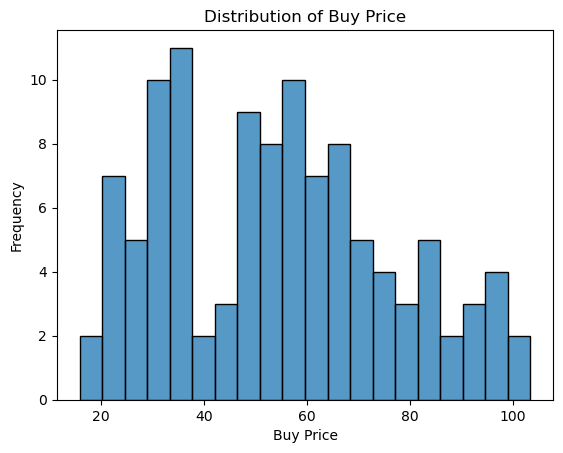

In [101]:
# Plot a histogram of buyPrice using matplotlib/seaborn.
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(products['buyPrice'], bins=20)
plt.xlabel('Buy Price')
plt.ylabel('Frequency')
plt.title('Distribution of Buy Price')
plt.show()

In [103]:
# Convert the orderDate column in orders to datetime format.
orders['orderDate'] = pd.to_datetime(orders['orderDate'])
orders

,orderNumber,orderDate,requiredDate,shippedDate,status,comments,customerNumber
0,10100,2003-01-06,2003-01-13,2003-01-10,Shipped,None,363
1,10101,2003-01-09,2003-01-18,2003-01-11,Shipped,Check on availability.,128
2,10102,2003-01-10,2003-01-18,2003-01-14,Shipped,None,181
3,10103,2003-01-29,2003-02-07,2003-02-02,Shipped,None,121
4,10104,2003-01-31,2003-02-09,2003-02-01,Shipped,None,141
...,...,...,...,...,...,...,...
321,10421,2005-05-29,2005-06-06,None,In Process,Custom shipping instructions were sent to ware...,124
322,10422,2005-05-30,2005-06-11,None,In Process,None,157
323,10423,2005-05-30,2005-06-05,None,In Process,None,314
324,10424,2005-05-31,2005-06-08,None,In Process,None,141


In [105]:
# Extract the year from orderDate and create a new column orderYear.
orders['orderYear'] = orders['orderDate'].dt.year
orders

,orderNumber,orderDate,requiredDate,shippedDate,status,comments,customerNumber,orderYear
0,10100,2003-01-06,2003-01-13,2003-01-10,Shipped,None,363,2003
1,10101,2003-01-09,2003-01-18,2003-01-11,Shipped,Check on availability.,128,2003
2,10102,2003-01-10,2003-01-18,2003-01-14,Shipped,None,181,2003
3,10103,2003-01-29,2003-02-07,2003-02-02,Shipped,None,121,2003
4,10104,2003-01-31,2003-02-09,2003-02-01,Shipped,None,141,2003
...,...,...,...,...,...,...,...,...
321,10421,2005-05-29,2005-06-06,None,In Process,Custom shipping instructions were sent to ware...,124,2005
322,10422,2005-05-30,2005-06-11,None,In Process,None,157,2005
323,10423,2005-05-30,2005-06-05,None,In Process,None,314,2005
324,10424,2005-05-31,2005-06-08,None,In Process,None,141,2005


In [106]:
print("Year:")
print(orders['orderDate'].dt.year)

print("Month:")
print(orders['orderDate'].dt.month)

print("Day:")
print(orders['orderDate'].dt.day)

print("Day Name:")
print(orders['orderDate'].dt.day_name())

print("Weekday:")
print(orders['orderDate'].dt.weekday)

Year:
0      2003
1      2003
2      2003
3      2003
4      2003
       ... 
321    2005
322    2005
323    2005
324    2005
325    2005
Name: orderDate, Length: 326, dtype: int32
Month:
0      1
1      1
2      1
3      1
4      1
      ..
321    5
322    5
323    5
324    5
325    5
Name: orderDate, Length: 326, dtype: int32
Day:
0       6
1       9
2      10
3      29
4      31
       ..
321    29
322    30
323    30
324    31
325    31
Name: orderDate, Length: 326, dtype: int32
Day Name:
0         Monday
1       Thursday
2         Friday
3      Wednesday
4         Friday
         ...    
321       Sunday
322       Monday
323       Monday
324      Tuesday
325      Tuesday
Name: orderDate, Length: 326, dtype: object
Weekday:
0      0
1      3
2      4
3      2
4      4
      ..
321    6
322    0
323    0
324    1
325    1
Name: orderDate, Length: 326, dtype: int32


In [107]:
# Find the number of null values per column in the orders DataFrame.
print(orders.isnull().sum())

orderNumber         0
orderDate           0
requiredDate        0
shippedDate        14
status              0
comments          246
customerNumber      0
orderYear           0
dtype: int64
